## NB4 — ROGUE Purity Audit per (sample, K, GEP)

**Pipeline:** NB1 (GSEA cell-type scoring) → NB2 (`per_gep_labels.tsv`) → NB4 (this notebook).

**What this notebook does:**
- Assigns each cell to every cNMF GEP it uses with sufficient confidence relative to its own top
  usage (soft/multi membership, `MIN_USAGE_RATIO`), per K — not a single winner-take-all argmax GEP.
- Scores every (sample, K, GEP) group with ROGUE, on cNMF's own HVG substrate.
- Runs three checks, kept explicitly separate rather than folded into one recommendation:
  1. **Contamination diagnostic** — label-matched subset of a GEP vs. the whole GEP.
  2. **Split/merge signal** — whole-GEP ROGUE vs. the original-annotation baseline.
  3. **Null control** — whole-GEP ROGUE vs. random same-size groups, same gene space.

**Gene space:** everything below uses cNMF's fixed HVG panel. Absolute ROGUE values are not
comparable to NB3's full-transcriptome scores or the 0.9 threshold from Liu et al. (2020) —
only deltas *within* this notebook are meaningful.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter
importr('ROGUE')
importr('tibble')  # ROGUE's SE_fun calls tibble() internally without qualifying it


rpy2.robjects.packages.Package as a <module 'tibble'>

### 1. Config

In [2]:
# Paths
ADATA_PATH = "hnc_data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None

METADATA_PATH = "hnc_data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL = None
METADATA_SEP = ","
BASELINE_LABEL_COL = "global.cluster4"

# Same cNMF outputs as NB1
CNMF_DIR = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35
N_HVG = 5000

# NB2 output — one label per (K, GEP)
LABELS_PATH = "hnc_combined5000hvg_clanp_results/k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"
LABELS_SEP = "\t"
AMBIGUOUS_LABEL = "Ambiguous/Mixed"
DROP_AMBIGUOUS = False
FAMILY_LABEL_SUFFIX = "_family"

# Must match NB2's family definitions
CELLTYPE_FAMILIES = {
    "Monocyte": [
        "Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
        "Mono_CD16", "Mono_Int", "Mono_TIL"
    ],
    "DC": [
        "cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "mregDC_LAMP3"
    ],
    "Macrophage": [
        "Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"
    ],
}

# ROGUE settings
ROGUE_PLATFORM = "UMI"
ROGUE_K = 45
MIN_CELLS_PER_GROUP = 15
DELTA_ROGUE_THRESHOLD = 0.05

# GEP membership (section 7): a cell "uses" a GEP if that GEP's usage share is >= MIN_USAGE_RATIO
# times the cell's OWN top usage share at this K (relative to the cell's own winner, not a fixed
# absolute cutoff — a fixed absolute floor doesn't generalize across K = 3..35, since cNMF's usage
# shares get smaller across more programs regardless of how "real" a program is for that cell).
# A cell can clear the bar for more than one GEP (soft/multi membership); it always keeps its top
# GEP (ratio <= 1), so no cell is ever dropped entirely — only extra credit is added on top.
MIN_USAGE_RATIO = 0.70

# Null control settings
N_NULL_DRAWS = 10
NULL_SIZE_BIN = 25   # round group sizes to the nearest N cells before drawing a null
RANDOM_SEED = 0

OUT_DIR = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


### 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)

meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)

samples = meta['orig.ident']
original_labels = meta[BASELINE_LABEL_COL].astype(str)

print(f"Aligned {len(common)} cells across {samples.nunique()} samples")
print(original_labels.value_counts().to_string())


Aligned 26444 cells across 63 samples
global.cluster4
Mono_CD14          7518
Mono_CD16          2503
Mac_IL1Bint        1842
Mono_CD14_IL1B     1801
Mono_CD14_THBS1    1783
Mono_Int           1684
cDC2_CD33          1319
Mac_CXCL9          1225
DC_pDC             1218
Mono_CD14_ID1      1154
Mono_TIL            988
cDC2_CD1C           966
Mac_IL1B            774
Mac_SPP1            573
mregDC_LAMP3        482
Mast                313
cDC1_CLEC9A         301


### 3. cNMF's HVG panel

- cNMF factorizes every K on one fixed gene panel, chosen once before K varies.
- Any `gene_spectra_score` file's columns are that panel — read one, verify the rest agree.
- `counts_df_hvg` is the gene space every ROGUE call below uses.


In [4]:
gene_spectra_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.gene_spectra_score.k_*.dt_{DENSITY_THRESHOLD}.txt"
)
gene_spectra_files = sorted(glob.glob(gene_spectra_pattern))
if not gene_spectra_files:
    raise FileNotFoundError(f"No gene_spectra_score files found matching {gene_spectra_pattern}")

hvg_genes = pd.read_csv(gene_spectra_files[0], sep='\t', index_col=0, nrows=0).columns.tolist()
for f in gene_spectra_files[1:]:
    other = pd.read_csv(f, sep='\t', index_col=0, nrows=0).columns.tolist()
    if other != hvg_genes:
        raise ValueError(f"Gene panel in {f} does not match {gene_spectra_files[0]}.")

missing_from_adata = [g for g in hvg_genes if g not in counts_df.index]
if missing_from_adata:
    raise ValueError(f"{len(missing_from_adata)} cNMF genes missing from AnnData, e.g. {missing_from_adata[:5]}")

counts_df_hvg = counts_df.loc[hvg_genes]
print(f"HVG panel: {len(hvg_genes)} genes (verified identical across {len(gene_spectra_files)} K values)")
print(f"HVG counts matrix: {counts_df_hvg.shape}")


HVG panel: 5000 genes (verified identical across 33 K values)
HVG counts matrix: (5000, 26444)


### 4. ROGUE scoring helpers

- `expr_full` is pushed to R once here and reused by every ROGUE call in this notebook.
- `rogue_for_cells` — ROGUE for one arbitrary set of cells.
- `rogue_for_groups` — ROGUE for every (sample, label) group in a labeled Series, within-sample.


In [5]:
ro.r("suppressMessages(library(ROGUE)); suppressMessages(library(tibble))")  # ROGUE's SE_fun calls tibble() unqualified — must be attached, not just imported
with CONVERTER.context():
    ro.globalenv['expr_full'] = counts_df_hvg
ro.r("expr_full <- as.matrix(expr_full)")

def rogue_for_cells(cell_ids):
    """ROGUE for one group of cells. Reuses expr_full already in the R session."""
    cell_ids = list(cell_ids)
    with CONVERTER.context():
        ro.globalenv['cells_keep'] = ro.StrVector(cell_ids)
    try:
        ro.r(f"""
            expr_mat  <- expr_full[, cells_keep, drop=FALSE]
            expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
            ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
            rogue_val <- CalculateRogue(ent_res, platform = "{ROGUE_PLATFORM}", k = {ROGUE_K})
        """)
        with CONVERTER.context():
            return float(ro.r('rogue_val')[0])
    except Exception:
        return float('nan')

def rogue_for_groups(labels, samples, min_cells=MIN_CELLS_PER_GROUP, desc="ROGUE"):
    """ROGUE per (sample, label), within-sample. Returns [sample, cluster, ROGUE, n_cells].

    `labels` (index = cell id, value = cluster/gep) may have a non-unique index — a cell can
    appear more than once under soft/multi membership. Grouping is done on plain columns, not
    index alignment, so a repeated cell id never triggers pandas' duplicate-index cross-join.
    """
    df = pd.DataFrame({'cell': labels.index, 'cluster': labels.values})
    df['sample'] = samples.loc[df['cell']].values

    counts = df['cluster'].value_counts()
    keep = counts[counts >= min_cells].index
    df = df[df['cluster'].isin(keep)]

    pairs = df.groupby(['sample', 'cluster']).size().reset_index(name='n_cells')
    pairs = pairs[pairs['n_cells'] >= min_cells]

    rows = []
    for row in tqdm(list(pairs.itertuples(index=False)), desc=desc):
        cells = df.loc[(df['sample'] == row.sample) & (df['cluster'] == row.cluster), 'cell']
        rows.append({'sample': row.sample, 'cluster': row.cluster,
                     'ROGUE': rogue_for_cells(cells), 'n_cells': row.n_cells})
    return pd.DataFrame(rows).dropna(subset=['ROGUE']).reset_index(drop=True)

### 5. NB2 per-GEP labels

- Loads `per_gep_labels.tsv`: one label per (K, GEP).
- A label is either an original `global.cluster4` cell type, a `<family>_family` label, or `Ambiguous/Mixed`.
- Anything else is flagged — it would silently fail to match a baseline later.


In [6]:
labels_df = pd.read_csv(LABELS_PATH, sep=LABELS_SEP)
required_cols = {"k", "gep", "label"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(f"per-GEP labels TSV missing columns {missing}. Got: {list(labels_df.columns)}")

labels_df['k']     = labels_df['k'].astype(int)
labels_df['gep']   = labels_df['gep'].astype(str)
labels_df['label'] = labels_df['label'].astype(str)
label_lookup = labels_df.set_index(['k', 'gep'])['label'].to_dict()

known_originals = set(original_labels.unique())
known_families  = {f"{fam}{FAMILY_LABEL_SUFFIX}" for fam in CELLTYPE_FAMILIES}
unknown = set(labels_df['label']) - known_originals - known_families - {AMBIGUOUS_LABEL}
if unknown:
    print(f"⚠ Labels not matching an original cell type or family: {sorted(unknown)}")

ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}

def label_kind(lbl):
    if lbl is None:                       return 'no_label'
    if lbl == AMBIGUOUS_LABEL:            return 'ambiguous'
    if lbl.endswith(FAMILY_LABEL_SUFFIX): return 'family'
    return 'specific'

print(f"Loaded {len(labels_df)} (k, gep) labels across K = {sorted(labels_df['k'].unique())}")
print(labels_df['label'].map(label_kind).value_counts().to_string())


Loaded 627 (k, gep) labels across K = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
label
ambiguous    452
family       105
specific      70


### 6. Baseline ROGUE — original labels

- ROGUE per (sample, original label), on the same HVG matrix everything else uses.
- Reference for `specific`-labeled GEPs in the split/merge signal (9).


In [7]:
baseline_specific_path = os.path.join(OUT_DIR, "rogue_baseline_specific.csv")
if os.path.exists(baseline_specific_path):
    baseline_specific = pd.read_csv(baseline_specific_path)
else:
    baseline_specific = rogue_for_groups(original_labels, samples, desc="Baseline (specific)")
    baseline_specific = baseline_specific.rename(columns={'cluster': 'original_label'})
    baseline_specific.to_csv(baseline_specific_path, index=False)

baseline_specific_lookup = baseline_specific.set_index(['sample', 'original_label'])['ROGUE'].to_dict()
print(baseline_specific.groupby('original_label')['ROGUE'].median().round(3).to_string())


Baseline (specific):   0%|          | 0/312 [00:00<?, ?it/s]

original_label
DC_pDC             0.960
Mac_CXCL9          0.880
Mac_IL1B           0.868
Mac_IL1Bint        0.857
Mac_SPP1           0.890
Mast               0.975
Mono_CD14          0.982
Mono_CD14_ID1      0.943
Mono_CD14_IL1B     0.977
Mono_CD14_THBS1    0.981
Mono_CD16          0.970
Mono_Int           0.974
Mono_TIL           0.898
cDC1_CLEC9A        0.963
cDC2_CD1C          0.883
cDC2_CD33          0.962
mregDC_LAMP3       0.927


### 6b. Baseline ROGUE — family pools

- Maps each cell's original label to `<family>_family`, pools by (sample, family), scores ROGUE.
- Reference for `family`-labeled GEPs in the split/merge signal (9).


In [8]:
baseline_family_path = os.path.join(OUT_DIR, "rogue_baseline_family.csv")

family_labels_per_cell = original_labels.map(
    lambda ct: f"{ct_to_family[ct]}{FAMILY_LABEL_SUFFIX}" if ct in ct_to_family else None
).dropna()

if os.path.exists(baseline_family_path):
    baseline_family = pd.read_csv(baseline_family_path)
else:
    baseline_family = rogue_for_groups(
        family_labels_per_cell, samples.loc[family_labels_per_cell.index],
        desc="Baseline (family)")
    baseline_family = baseline_family.rename(columns={'cluster': 'family_label'})
    baseline_family.to_csv(baseline_family_path, index=False)

baseline_family_lookup = baseline_family.set_index(['sample', 'family_label'])['ROGUE'].to_dict()
print(baseline_family.groupby('family_label')['ROGUE'].median().round(3).to_string())


Baseline (family):   0%|          | 0/132 [00:00<?, ?it/s]

family_label
DC_family            0.944
Macrophage_family    0.757
Monocyte_family      0.929


### 7. Whole-GEP ROGUE per (sample, K, GEP)

- For each K: assign cells to GEPs by **soft/multi membership**, not winner-take-all argmax. A
  cell counts as using a GEP if that GEP's usage share is ≥ `MIN_USAGE_RATIO` × the cell's own
  top usage share at this K — relative to that cell's own winner, not a fixed absolute cutoff
  (a fixed floor doesn't generalize across K = 3..35, since usage shares shrink with more
  programs regardless of how real a program is for that cell). A cell always keeps its top GEP
  and can additionally clear the bar for others; no cell is ever dropped entirely.
- Drop cells whose GEP has no NB2 label; optionally drop `Ambiguous/Mixed` GEPs (`DROP_AMBIGUOUS`).
- Score ROGUE per (sample, GEP), within-sample so batch effects aren't read as impurity.
- `gep_ids_by_k` (per-cell GEP membership) stays in memory — 8 reuses it directly instead of re-reading usage matrices.
- Cache filenames are tagged with `MIN_USAGE_RATIO` (`_softratio{MIN_USAGE_RATIO}`) so they never
  silently mix with results computed under the old argmax method.

In [9]:
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = sorted({
    int(m.group(1))
    for f in glob.glob(usage_pattern)
    if (m := re.search(r'k_(\d+)', os.path.basename(f))) and K_MIN <= int(m.group(1)) <= K_MAX
})
k_values = [k for k in k_values if k in set(labels_df['k'].unique())]
print(f"K values: {k_values}")

def load_soft_gep_ids(k, ratio=MIN_USAGE_RATIO):
    """Soft/multi GEP membership for K: a cell counts as using a GEP if that GEP's usage share
    is >= ratio * the cell's own top usage share at this K. Returns a Series (index=cell id,
    value=gep) whose index can repeat once per GEP a cell qualifies for; every cell keeps at
    least its top GEP, so no cell is ever dropped entirely."""
    usage_path = os.path.join(
        CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
    )
    u = pd.read_csv(usage_path, sep='\t', index_col=0)
    u.index, u.columns = u.index.astype(str), u.columns.astype(str)
    u = u.loc[u.index.intersection(counts_df_hvg.columns)]
    u_share = u.div(u.sum(axis=1), axis=0)  # usage matrix rows don't sum to 1 on their own
    row_max = u_share.max(axis=1)
    long = u_share.where(u_share.ge(ratio * row_max, axis=0)).stack()
    long = long.reset_index()
    long.columns = ['cell', 'gep', 'usage_share']
    return long.set_index('cell')['gep'].astype(str)

gep_ids_by_k = {k: load_soft_gep_ids(k) for k in k_values}

MEMBERSHIP_TAG = f"softratio{MIN_USAGE_RATIO}"

def _gep_out_path(k):
    return os.path.join(OUT_DIR, f"rogue_per_gep_{MEMBERSHIP_TAG}_K{k}.csv")

gep_rogue_parts = []
for k in k_values:
    out_path = _gep_out_path(k)
    if os.path.exists(out_path):
        gep_rogue_parts.append(pd.read_csv(out_path, dtype={'gep': str, 'label': str}))
        continue

    gep_ids = gep_ids_by_k[k]
    gep_ids = gep_ids[gep_ids.map(lambda g: (k, g) in label_lookup)]
    if DROP_AMBIGUOUS:
        keep = {g for g in gep_ids.unique() if label_lookup[(k, g)] != AMBIGUOUS_LABEL}
        gep_ids = gep_ids[gep_ids.isin(keep)]

    long = rogue_for_groups(gep_ids, samples, desc=f"K={k}")
    long = long.rename(columns={'cluster': 'gep'})
    long['K'] = k
    long['label'] = long['gep'].map(lambda g: label_lookup.get((k, g)))
    long['label_kind'] = long['label'].map(label_kind)
    long = long[['sample', 'K', 'gep', 'label', 'label_kind', 'ROGUE', 'n_cells']]
    long.to_csv(out_path, index=False)
    gep_rogue_parts.append(long)

gep_rogue = pd.concat(gep_rogue_parts, ignore_index=True)
print(f"{len(gep_rogue)} (sample, K, GEP) rows")
print(gep_rogue['label_kind'].value_counts().to_string())

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


K=3:   0%|          | 0/118 [00:00<?, ?it/s]

K=4:   0%|          | 0/133 [00:00<?, ?it/s]

K=5:   0%|          | 0/139 [00:00<?, ?it/s]

K=6:   0%|          | 0/161 [00:00<?, ?it/s]

...

K=32:   0%|          | 0/79 [00:00<?, ?it/s]

K=33:   0%|          | 0/208 [00:00<?, ?it/s]

K=34:   0%|          | 0/270 [00:00<?, ?it/s]

K=35:   0%|          | 0/338 [00:00<?, ?it/s]

7288 (sample, K, GEP) rows
label_kind
ambiguous    3597
specific     2014
family       1677


### 8. Comparison 1 — Contamination diagnostic

- For each GEP, take only the cells whose *original* label matches the GEP's NB2 label
  (exact match for `specific`, any family member for `family`).
- Score that label-matched subset and compare it to the whole GEP's ROGUE.
- A subset restricted to one label is expected to be at least as pure as the mixed GEP it
  came from — that's structural, not evidence of a real subtype.
- Read this as **contamination**, not a split/merge signal: a large gap means the GEP pulled
  in a lot of cells the original annotation didn't call this label.


In [10]:
def matched_cells(sample, k, gep, label, kind):
    cells = gep_ids_by_k[k].index[gep_ids_by_k[k] == gep]
    cells = cells.intersection(samples.index[samples == sample])
    if kind == 'specific':
        target = {label}
    elif kind == 'family':
        target = set(CELLTYPE_FAMILIES.get(label[:-len(FAMILY_LABEL_SUFFIX)], []))
    else:
        return cells[:0]
    return cells[original_labels.loc[cells].isin(target)]

contam_path = os.path.join(OUT_DIR, f"rogue_contamination_{MEMBERSHIP_TAG}.csv")
if os.path.exists(contam_path):
    contamination = pd.read_csv(contam_path)
else:
    scoreable = gep_rogue[gep_rogue['label_kind'].isin(['specific', 'family'])]
    rows = []
    for r in tqdm(list(scoreable.itertuples(index=False)), desc="Contamination"):
        cells = matched_cells(r.sample, r.K, r.gep, r.label, r.label_kind)
        n_matched = len(cells)
        subset_rogue = rogue_for_cells(cells) if n_matched >= MIN_CELLS_PER_GROUP else np.nan
        rows.append({
            'sample': r.sample, 'K': r.K, 'gep': r.gep, 'label': r.label,
            'label_kind': r.label_kind, 'whole_gep_ROGUE': r.ROGUE, 'whole_gep_n_cells': r.n_cells,
            'matched_n_cells': n_matched, 'matched_frac': n_matched / r.n_cells,
            'matched_ROGUE': subset_rogue,
            'contamination_delta': subset_rogue - r.ROGUE if not pd.isna(subset_rogue) else np.nan,
        })
    contamination = pd.DataFrame(rows)
    contamination.to_csv(contam_path, index=False)

print(f"{len(contamination)} rows scored")
print(contamination[['matched_frac', 'contamination_delta']].describe().round(3).to_string())

Contamination:   0%|          | 0/3691 [00:00<?, ?it/s]

3691 rows scored
       matched_frac  contamination_delta
count      3691.000             2686.000
mean          0.593                0.032
std           0.395                0.048
min           0.000               -0.052
25%           0.154                0.000
50%           0.731                0.009
75%           0.980                0.051
max           1.000                0.343


### 9. Comparison 2 — Split/merge signal

- Whole-GEP ROGUE vs. the original-annotation baseline for that label:
  `baseline_specific` for `specific` labels, `baseline_family` for `family` labels.
- This is the legitimate "did cNMF's grouping beat the original annotation" question — both
  sides are ROGUE on the same HVG matrix, so the delta is comparable.
- `ambiguous` / `no_label` GEPs have no baseline and are reported as such, not scored.


In [11]:
def split_merge_baseline(row):
    if row['label_kind'] == 'specific':
        return baseline_specific_lookup.get((row['sample'], row['label']), np.nan)
    if row['label_kind'] == 'family':
        return baseline_family_lookup.get((row['sample'], row['label']), np.nan)
    return np.nan

def tag_delta(delta):
    if pd.isna(delta):                  return 'no_baseline'
    if delta >=  DELTA_ROGUE_THRESHOLD: return 'purer'
    if delta <= -DELTA_ROGUE_THRESHOLD: return 'less_pure'
    return 'tie'

split_merge = gep_rogue.copy()
split_merge['baseline_ROGUE'] = split_merge.apply(split_merge_baseline, axis=1)
split_merge['delta_ROGUE'] = split_merge['ROGUE'] - split_merge['baseline_ROGUE']
split_merge.loc[split_merge['label_kind'] == 'ambiguous', 'delta_ROGUE'] = np.nan
split_merge['recommendation'] = split_merge['delta_ROGUE'].map(tag_delta)
split_merge.loc[split_merge['label_kind'].isin(['ambiguous', 'no_label']), 'recommendation'] = split_merge['label_kind']

out = os.path.join(OUT_DIR, f"rogue_split_merge_signal_{MEMBERSHIP_TAG}.csv")
split_merge.to_csv(out, index=False)
print(split_merge['recommendation'].value_counts().to_string())

recommendation
ambiguous      3597
tie            1600
no_baseline     779
purer           707
less_pure       605


### 10. Comparison 3 — Null / chance control

- cNMF defines GEPs *and* ROGUE scores them in the same HVG space — a GEP can look pure just
  because it was built to be internally coherent in that space, independent of biology.
- Null: for each (sample, group-size bin), draw `N_NULL_DRAWS` random same-size cell groups
  from that sample's full pool and score them the same way.
- A GEP only counts as evidence of real structure if it beats this null — beating the
  original-label baseline (9) alone isn't enough, since that baseline says nothing about
  what random groups in this same gene space would already look like.


In [12]:
rng = np.random.default_rng(RANDOM_SEED)

def size_bin(n, width=NULL_SIZE_BIN):
    return max(width, int(round(n / width) * width))

gep_rogue['size_bin'] = gep_rogue['n_cells'].map(size_bin)
null_needed = gep_rogue[['sample', 'size_bin']].drop_duplicates()

null_path = os.path.join(OUT_DIR, "rogue_null_draws.csv")
if os.path.exists(null_path):
    null_draws = pd.read_csv(null_path)
else:
    rows = []
    for r in tqdm(list(null_needed.itertuples(index=False)), desc="Null draws"):
        pool = np.array(samples.index[samples == r.sample].intersection(counts_df_hvg.columns))
        if len(pool) < r.size_bin:
            continue
        for draw in range(N_NULL_DRAWS):
            cells = rng.choice(pool, size=r.size_bin, replace=False)
            rows.append({'sample': r.sample, 'size_bin': r.size_bin, 'draw': draw,
                        'ROGUE': rogue_for_cells(cells)})
    null_draws = pd.DataFrame(rows).dropna(subset=['ROGUE'])
    null_draws.to_csv(null_path, index=False)

null_summary = (null_draws.groupby(['sample', 'size_bin'])['ROGUE']
                .agg(null_median='median', null_mean='mean', null_std='std', n_draws='count')
                .reset_index())

null_control = gep_rogue.merge(null_summary, on=['sample', 'size_bin'], how='left')
null_control['null_zscore'] = (
    (null_control['ROGUE'] - null_control['null_mean']) / null_control['null_std']
)
null_control['beats_null_median'] = null_control['ROGUE'] > null_control['null_median']

out = os.path.join(OUT_DIR, f"rogue_null_control_{MEMBERSHIP_TAG}.csv")
null_control.to_csv(out, index=False)
print(f"Beats null median: {null_control['beats_null_median'].mean():.1%} of rows")
print(null_control.groupby('label_kind')['beats_null_median'].mean().round(3).to_string())

Null draws:   0%|          | 0/894 [00:00<?, ?it/s]

Beats null median: 69.3% of rows
label_kind
ambiguous    0.641
family       0.776
specific     0.719


### 11. GEP Tree Diagram — ROGUE-Annotated

- Redraws NB2's GEP tree (7b there) from the edge list NB2 now persists to `gep_tree_edges.csv`,
  using the same node layout and parent-celltype edge coloring.
- Each node is additionally labeled with its whole-GEP ROGUE score (median across samples, from 7 above).
- Node **shape** carries label kind: circle = a specific cell type (terminal label), square =
  `<family>_family` or `Ambiguous/Mixed`.
- A panel below the tree tracks, at each K, the median ROGUE of specific/terminal GEPs minus the
  median ROGUE of family/ambiguous GEPs — whether cNMF's terminal calls are cleaner than its mixed
  ones at that K, and how that gap moves as K grows.
- `TREE_K_START` / `TREE_K_STOP` control which K levels are drawn — the full K range is too dense
  to read per-node scores in, so narrow it to the slice you want to inspect.

In [13]:
# K range to draw. Defaults to the full range NB2 built; narrow it to zoom in.
TREE_K_START = 3
TREE_K_STOP  = 35

# NB2 writes gep_tree_edges.csv into the same directory as per_gep_labels.tsv
CORR_TREE_DIR = os.path.dirname(LABELS_PATH)
EDGES_PATH = os.path.join(CORR_TREE_DIR, "gep_tree_edges.csv")
if not os.path.exists(EDGES_PATH):
    raise FileNotFoundError(
        f"{EDGES_PATH} not found — re-run NB2 section 5 (edge-list build) to persist it."
    )

tree_edges_df = pd.read_csv(EDGES_PATH, dtype={'parent_gep': str, 'child_gep': str})
tree_edges_df = tree_edges_df[
    (tree_edges_df['k_parent'] >= TREE_K_START) & (tree_edges_df['k_child'] <= TREE_K_STOP)
]

tree_labels_df = labels_df[(labels_df['k'] >= TREE_K_START) & (labels_df['k'] <= TREE_K_STOP)]
if tree_labels_df.empty:
    raise ValueError(f"No GEPs labeled in K={TREE_K_START}..{TREE_K_STOP} — check the range.")

print(f"K range: {TREE_K_START}..{TREE_K_STOP}  |  "
      f"{len(tree_edges_df)} edges, {len(tree_labels_df)} nodes")


K range: 3..35  |  624 edges, 627 nodes


In [14]:
# One ROGUE score per (K, GEP) node: median across the samples scored for it in 7.
node_rogue = (
    gep_rogue[(gep_rogue['K'] >= TREE_K_START) & (gep_rogue['K'] <= TREE_K_STOP)]
    .groupby(['K', 'gep'])['ROGUE']
    .median()
    .to_dict()
)

# Cell-type color palette, same scheme as NB2 7b — used for both node fill and edge color
# (parent cell type).
def _is_family_label(lbl):
    return lbl.endswith(FAMILY_LABEL_SUFFIX)

all_labels = set(tree_labels_df['label'])
family_labels = sorted(l for l in all_labels if _is_family_label(l))
specific_cts  = sorted(l for l in all_labels if l != AMBIGUOUS_LABEL and not _is_family_label(l))

tab20_non_gray = [plt.cm.tab20(i) for i in range(20) if i not in (14, 15)]
set1_non_gray  = [plt.cm.Set1(i) for i in range(9) if i != 8]

ct_colors = {ct: tab20_non_gray[i % len(tab20_non_gray)] for i, ct in enumerate(specific_cts)}
ct_colors.update({fam: set1_non_gray[i % len(set1_non_gray)] for i, fam in enumerate(family_labels)})
if AMBIGUOUS_LABEL in all_labels:
    ct_colors[AMBIGUOUS_LABEL] = '#888888'

all_celltypes = specific_cts + family_labels + ([AMBIGUOUS_LABEL] if AMBIGUOUS_LABEL in all_labels else [])

# Node marker shape: circle = specific cell type (terminal label), square = family/ambiguous/mixed.
def label_kind_marker(kind):
    return 'o' if kind == 'specific' else 's'

print(f"{len(all_celltypes)} label colors, {len(node_rogue)} nodes with a ROGUE score")


11 label colors, 333 nodes with a ROGUE score


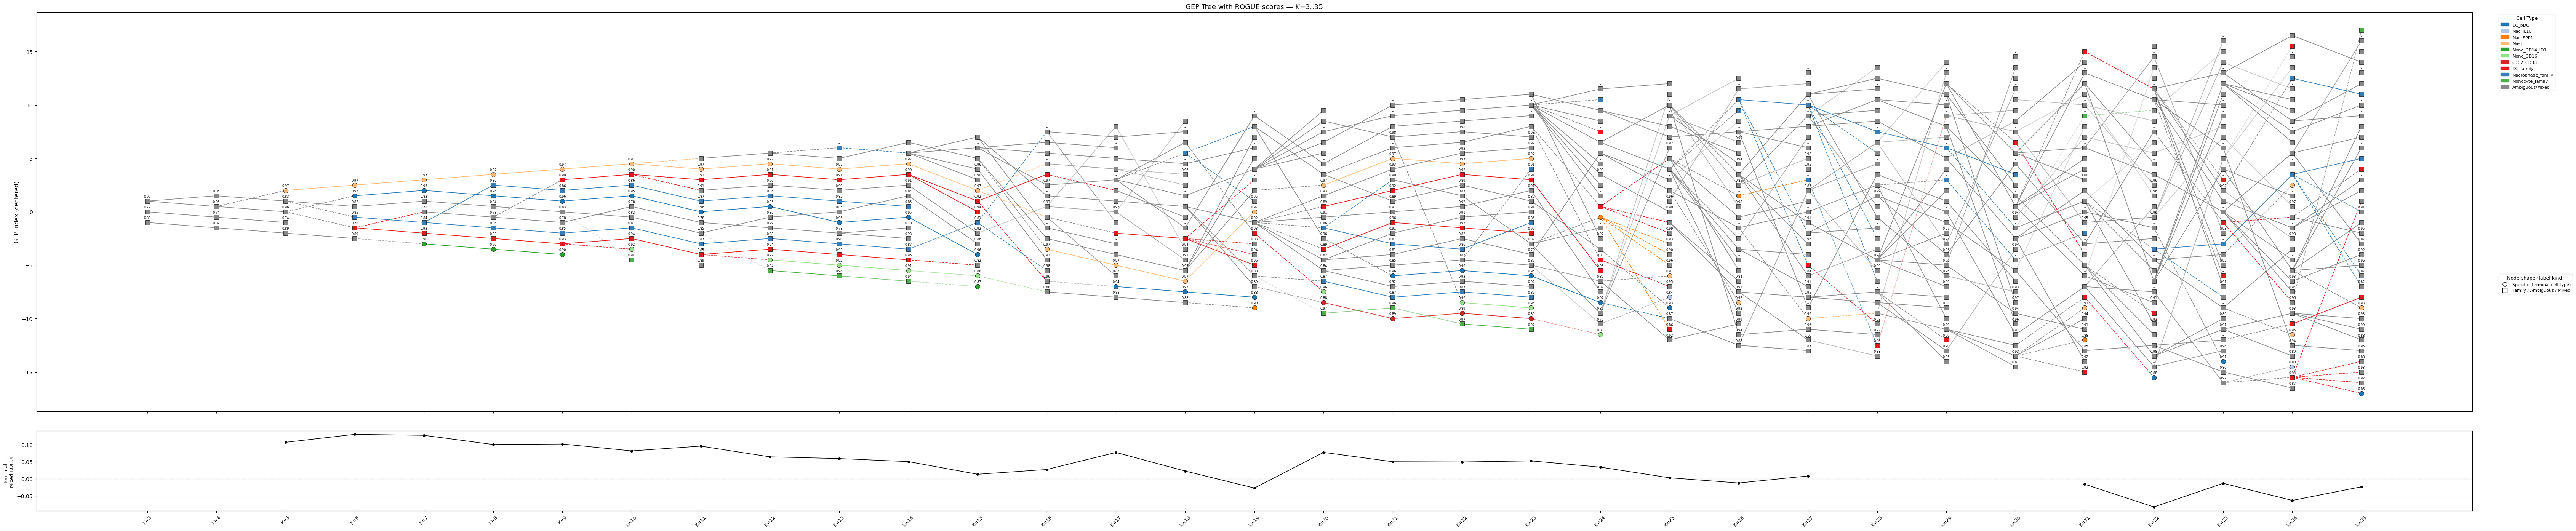

In [15]:
from matplotlib.lines import Line2D

def _gep_sort_key(g):
    try:
        return (0, int(g))
    except ValueError:
        return (1, g)

tree_k_values = sorted(tree_labels_df['k'].unique())

node_pos = {}
for xi, k in enumerate(tree_k_values):
    geps_at_k = sorted(tree_labels_df.loc[tree_labels_df['k'] == k, 'gep'].unique(), key=_gep_sort_key)
    n_geps = len(geps_at_k)
    for yi, gep in enumerate(geps_at_k):
        node_pos[(k, gep)] = (xi, yi - (n_geps - 1) / 2)

# Per-K signal for the panel below: median ROGUE of terminal (specific-label) GEPs minus
# median ROGUE of mixed (family/ambiguous-label) GEPs.
diff_by_k = []
for k in tree_k_values:
    geps_at_k = tree_labels_df.loc[tree_labels_df['k'] == k, 'gep']
    kinds = {g: label_kind(label_lookup.get((k, g))) for g in geps_at_k}
    specific_vals = [node_rogue[(k, g)] for g, kind in kinds.items() if kind == 'specific' and (k, g) in node_rogue]
    mixed_vals    = [node_rogue[(k, g)] for g, kind in kinds.items() if kind in ('family', 'ambiguous') and (k, g) in node_rogue]
    specific_med = np.median(specific_vals) if specific_vals else np.nan
    mixed_med    = np.median(mixed_vals) if mixed_vals else np.nan
    diff_by_k.append(specific_med - mixed_med)

fig, (ax, ax2) = plt.subplots(
    2, 1, sharex=True,
    figsize=(max(20, len(tree_k_values) * 2.5), max(10, max(tree_k_values) * 0.4) + 3),
    gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.08},
)

# Edges: same convention as NB2 — color = parent's cell type, alpha = similarity,
# solid = cell-type match, dashed = mismatch.
for row in tree_edges_df[tree_edges_df['parent_gep'].notna()].itertuples(index=False):
    p_key = (row.k_parent, row.parent_gep)
    c_key = (row.k_child, row.child_gep)
    if p_key in node_pos and c_key in node_pos:
        px, py = node_pos[p_key]
        cx, cy = node_pos[c_key]
        alpha = min(1.0, max(0.15, row.similarity))
        color = ct_colors.get(row.parent_celltype, 'black')
        ls = '-' if row.celltype_match else '--'
        ax.plot([px, cx], [py, cy], color=color, alpha=alpha, lw=1.2, ls=ls, zorder=1)

# Nodes: fill color = cell type (same scheme as NB2), marker shape = terminal (circle) vs
# family/mixed (square). ROGUE score is still printed above each node.
for (k, gep), (x, y) in node_pos.items():
    ct = label_lookup.get((k, gep), AMBIGUOUS_LABEL)
    kind = label_kind(ct)
    color = ct_colors.get(ct, 'black')
    marker = label_kind_marker(kind)
    ax.scatter(x, y, c=[color], marker=marker, s=80, edgecolors='black', linewidths=0.5, zorder=2)

    rogue_val = node_rogue.get((k, gep))
    label_txt = f"{rogue_val:.2f}" if rogue_val is not None and not pd.isna(rogue_val) else "–"
    ax.annotate(label_txt, (x, y), xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=6, color='black', zorder=3)

ax.set_xticks(range(len(tree_k_values)))
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('GEP index (centered)', fontsize=11)
ax.set_title(f'GEP Tree with ROGUE scores — K={TREE_K_START}..{TREE_K_STOP}', fontsize=13)

ct_patches = [mpatches.Patch(color=ct_colors[ct], label=ct) for ct in all_celltypes]
legend_ct = ax.legend(handles=ct_patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
                       fontsize=8, title='Cell Type', title_fontsize=9)
ax.add_artist(legend_ct)

shape_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='white', markeredgecolor='black',
           markersize=8, label='Specific (terminal cell type)'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='white', markeredgecolor='black',
           markersize=8, label='Family / Ambiguous / Mixed'),
]
ax.legend(handles=shape_handles, loc='upper left', bbox_to_anchor=(1.01, 0.35),
          fontsize=8, title='Node shape (label kind)', title_fontsize=9)

# Panel below: at each K, median ROGUE of terminal (specific) GEPs minus median ROGUE of
# family/ambiguous GEPs — positive means terminal calls are cleaner than mixed ones at that K.
ax2.axhline(0, color='gray', lw=0.8, ls='--', zorder=1)
ax2.plot(range(len(tree_k_values)), diff_by_k, color='black', marker='o', markersize=4, lw=1.2, zorder=2)
ax2.set_ylabel('Terminal −\nMixed ROGUE', fontsize=9)
ax2.set_xticks(range(len(tree_k_values)))
ax2.set_xticklabels([f'K={k}' for k in tree_k_values], fontsize=9, rotation=45)
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

plt.savefig(os.path.join(OUT_DIR, f"gep_tree_rogue_K{TREE_K_START}-{TREE_K_STOP}.png"), dpi=150, bbox_inches='tight')
plt.show()


### 12. ROGUE distribution by label — all GEPs

- One value per **GEP node** `(K, gep)`: its whole-GEP ROGUE, median across samples (same
  aggregation as the tree in 11, but here over the full `K_MIN..K_MAX` range instead of a
  narrowed slice).
- Boxplot grouped by the GEP's NB2 label (specific cell type / `<family>_family` / `Ambiguous/Mixed`)
  on the x-axis, one dot per GEP node overlaid on each box, sample size `n` printed under each
  label.

333 GEP nodes (K=3..35) across 11 labels


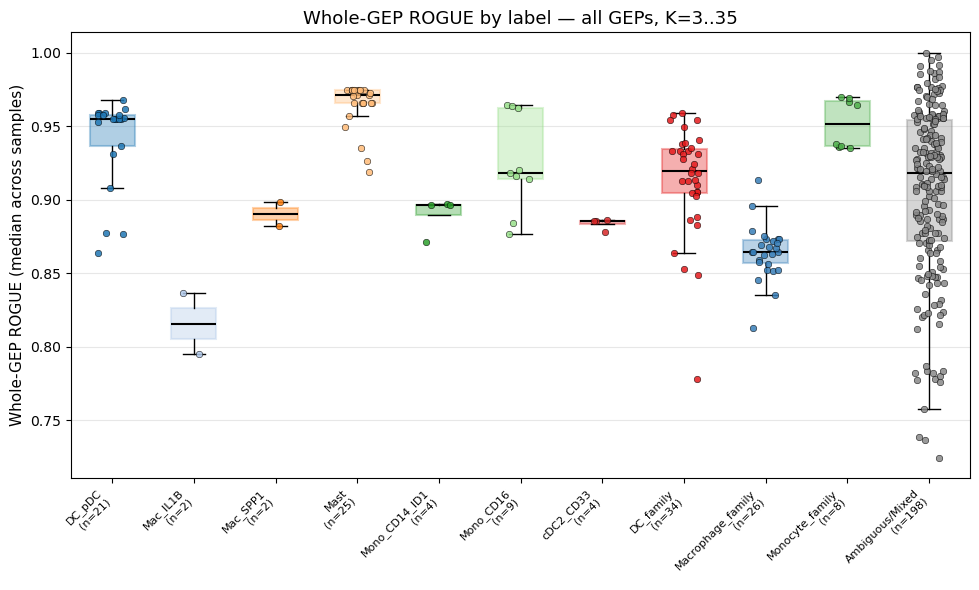

In [16]:
# One ROGUE value per GEP node, over the full K range (not narrowed to a TREE_K_START..STOP slice).
node_rogue_df = gep_rogue.groupby(['K', 'gep'])['ROGUE'].median().reset_index()
node_rogue_df['label'] = node_rogue_df.apply(lambda r: label_lookup.get((r['K'], r['gep'])), axis=1)
node_rogue_df = node_rogue_df.dropna(subset=['label']).reset_index(drop=True)
node_rogue_df['label_kind'] = node_rogue_df['label'].map(label_kind)

# Same color scheme as 11 (tab20 for specific cell types, Set1 for families, gray for Ambiguous/Mixed),
# rebuilt here since 11's ct_colors is scoped to its own TREE_K_START..STOP slice.
tab20_non_gray = [plt.cm.tab20(i) for i in range(20) if i not in (14, 15)]
set1_non_gray  = [plt.cm.Set1(i) for i in range(9) if i != 8]

def build_label_colors(labels_present):
    fam  = sorted(l for l in labels_present if l.endswith(FAMILY_LABEL_SUFFIX))
    spec = sorted(l for l in labels_present if l != AMBIGUOUS_LABEL and not l.endswith(FAMILY_LABEL_SUFFIX))
    colors = {ct: tab20_non_gray[i % len(tab20_non_gray)] for i, ct in enumerate(spec)}
    colors.update({f: set1_non_gray[i % len(set1_non_gray)] for i, f in enumerate(fam)})
    if AMBIGUOUS_LABEL in labels_present:
        colors[AMBIGUOUS_LABEL] = '#888888'
    order = spec + fam + ([AMBIGUOUS_LABEL] if AMBIGUOUS_LABEL in labels_present else [])
    return colors, order

def plot_gep_rogue_boxplot(node_df, colors, order, title, out_name, jitter_seed=RANDOM_SEED):
    """Boxplot of per-GEP-node ROGUE, grouped by label, one dot per node, n printed under each label."""
    order = [l for l in order if l in set(node_df['label'])]
    data = [node_df.loc[node_df['label'] == lbl, 'ROGUE'].values for lbl in order]
    counts = [len(d) for d in data]
    positions = np.arange(1, len(order) + 1)

    fig, ax = plt.subplots(figsize=(max(8, len(order) * 0.9), 6))

    bp = ax.boxplot(data, positions=positions, widths=0.55, patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', linewidth=1.5),
                     whiskerprops=dict(color='black'), capprops=dict(color='black'))
    for patch, lbl in zip(bp['boxes'], order):
        color = colors.get(lbl, '#888888')
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)

    rng_jitter = np.random.default_rng(jitter_seed)
    for pos, vals, lbl in zip(positions, data, order):
        if len(vals) == 0:
            continue
        x_jitter = pos + rng_jitter.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(x_jitter, vals, s=22, color=colors.get(lbl, '#888888'),
                   edgecolors='black', linewidths=0.4, alpha=0.85, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels([f"{lbl}\n(n={n})" for lbl, n in zip(order, counts)],
                        rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Whole-GEP ROGUE (median across samples)', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, out_name), dpi=150, bbox_inches='tight')
    plt.show()

all_node_labels = set(node_rogue_df['label'])
label_colors, label_order = build_label_colors(all_node_labels)
print(f"{len(node_rogue_df)} GEP nodes (K={node_rogue_df['K'].min()}..{node_rogue_df['K'].max()}) across {len(label_order)} labels")

plot_gep_rogue_boxplot(
    node_rogue_df, label_colors, label_order,
    title=f"Whole-GEP ROGUE by label — all GEPs, K={K_MIN}..{K_MAX}",
    out_name="rogue_boxplot_by_label_all_geps.png",
)


### 13. ROGUE distribution by label — terminal GEPs only

- Same plot as 12, restricted to **terminal nodes**: GEPs with no child edge into K+1 in
  `gep_tree_edges.csv` (read fresh here, unfiltered by `TREE_K_START`/`TREE_K_STOP`). This
  includes genuine leaves of the tree as well as every node at `K_MAX`, which has no K+1 to
  connect to by construction.

121 / 333 GEP nodes are terminal (no child at K+1)


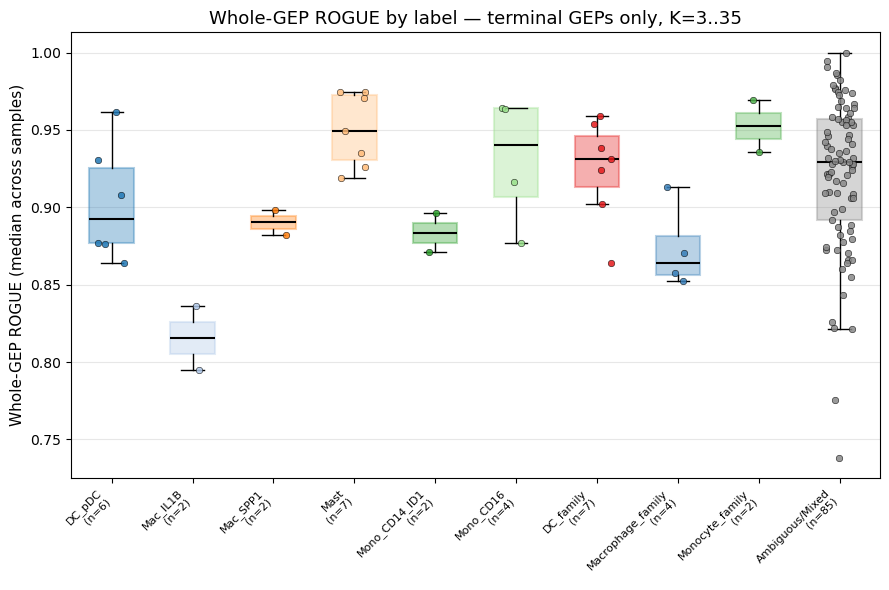

In [17]:
# Full edge list, unfiltered by TREE_K_START/TREE_K_STOP — need every K level to find terminal nodes.
full_tree_edges_df = pd.read_csv(EDGES_PATH, dtype={'parent_gep': str, 'child_gep': str})
has_child = set(
    zip(full_tree_edges_df.loc[full_tree_edges_df['parent_gep'].notna(), 'k_parent'],
        full_tree_edges_df.loc[full_tree_edges_df['parent_gep'].notna(), 'parent_gep'])
)

node_rogue_df['is_terminal'] = ~node_rogue_df.apply(lambda r: (r['K'], r['gep']) in has_child, axis=1)
terminal_node_df = node_rogue_df[node_rogue_df['is_terminal']].reset_index(drop=True)

terminal_labels = set(terminal_node_df['label'])
terminal_colors, terminal_order = build_label_colors(terminal_labels)
print(f"{len(terminal_node_df)} / {len(node_rogue_df)} GEP nodes are terminal (no child at K+1)")

plot_gep_rogue_boxplot(
    terminal_node_df, terminal_colors, terminal_order,
    title=f"Whole-GEP ROGUE by label — terminal GEPs only, K={K_MIN}..{K_MAX}",
    out_name="rogue_boxplot_by_label_terminal_geps.png",
)


### 14. Split/merge signal — category breakdown

How the 9 `recommendation` tag (purer / tie / less_pure / no_baseline / ambiguous) splits across all 6,211 (sample, K, GEP) rows.

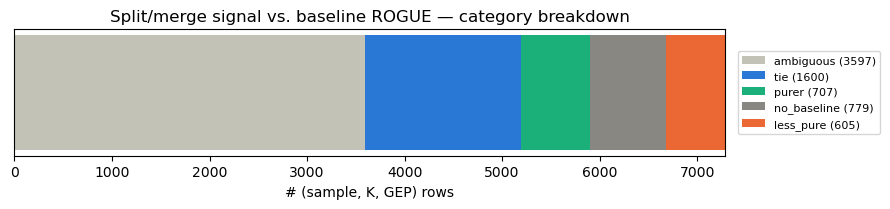

In [18]:
rec_order = ['ambiguous', 'tie', 'purer', 'no_baseline', 'less_pure']
rec_counts = split_merge['recommendation'].value_counts().reindex(rec_order, fill_value=0)
rec_colors = {'ambiguous': '#c3c2b7', 'tie': '#2a78d6', 'purer': '#1baf7a',
              'no_baseline': '#898781', 'less_pure': '#eb6834'}

fig, ax = plt.subplots(figsize=(9, 2.2))
left = 0
for cat in rec_order:
    v = rec_counts[cat]
    ax.barh(0, v, left=left, color=rec_colors[cat], label=f"{cat} ({v})")
    left += v
ax.set_yticks([])
ax.set_xlim(0, left)
ax.set_xlabel('# (sample, K, GEP) rows')
ax.set_title('Split/merge signal vs. baseline ROGUE — category breakdown')
ax.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "split_merge_signal_breakdown.png"), dpi=150, bbox_inches='tight')
plt.show()

### 15. Null-control pass rate by label kind

Share of 10 rows whose whole-GEP ROGUE beats the median of its null draws, split by `label_kind`. Ambiguous-label GEPs pass least often — expected, since they have the least coherent identity to begin with.

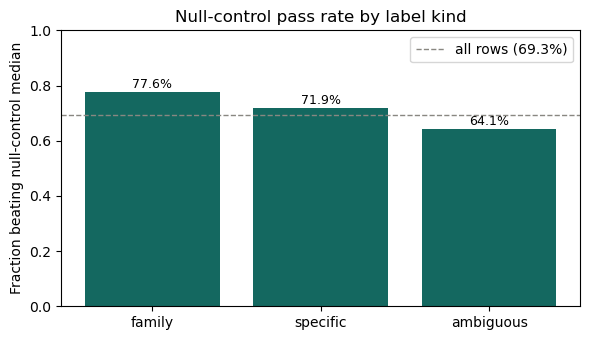

In [19]:
pass_rate = null_control.groupby('label_kind')['beats_null_median'].mean().reindex(
    ['family', 'specific', 'ambiguous']
)
overall_rate = null_control['beats_null_median'].mean()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(pass_rate.index, pass_rate.values, color='#146860')
ax.axhline(overall_rate, color='#898781', ls='--', lw=1, label=f"all rows ({overall_rate:.1%})")
for i, v in enumerate(pass_rate.values):
    ax.text(i, v + 0.015, f"{v:.1%}", ha='center', fontsize=9)
ax.set(ylabel='Fraction beating null-control median', ylim=(0, 1),
       title='Null-control pass rate by label kind')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "null_control_pass_rate_by_kind.png"), dpi=150, bbox_inches='tight')
plt.show()

### 16. GEP usage vs. ROGUE

- One point per **GEP node** `(K, gep)`, same population as 12: `node_rogue_df`.
- x-axis: **GEP usage** — total number of cells counted toward that GEP under the soft/multi
  membership rule from 7 (summed `n_cells` across samples in `gep_rogue`), log-scaled since usage
  spans orders of magnitude across K = 3..35. Because membership is soft, a cell can contribute
  to more than one GEP's usage count.
- y-axis: whole-GEP ROGUE (median across samples, same as 12/13).
- Color = NB2 label, same palette as 12; marker shape = label kind (circle = specific, square =
  family/ambiguous), same convention as the tree in 11.

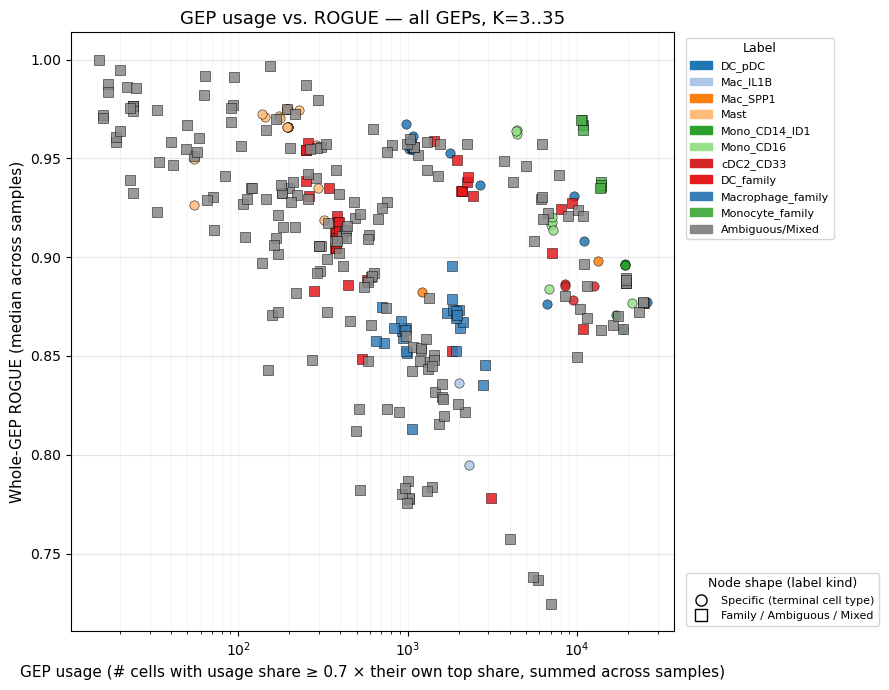

In [20]:
# Total usage per GEP node: sum of soft-membership n_cells across all samples scored for it in 7.
node_usage = gep_rogue.groupby(['K', 'gep'])['n_cells'].sum().rename('usage_n_cells')
usage_df = node_rogue_df.merge(node_usage, on=['K', 'gep'], how='left')

fig, ax = plt.subplots(figsize=(9, 7))

for lbl in label_order:
    sub = usage_df[usage_df['label'] == lbl]
    if sub.empty:
        continue
    kind = label_kind(lbl)
    ax.scatter(sub['usage_n_cells'], sub['ROGUE'],
               c=[label_colors.get(lbl, '#888888')], marker=label_kind_marker(kind),
               s=45, edgecolors='black', linewidths=0.4, alpha=0.85, label=lbl, zorder=3)

ax.set_xscale('log')
ax.set_xlabel(f'GEP usage (# cells with usage share ≥ {MIN_USAGE_RATIO} × their own top share, summed across samples)', fontsize=11)
ax.set_ylabel('Whole-GEP ROGUE (median across samples)', fontsize=11)
ax.set_title(f'GEP usage vs. ROGUE — all GEPs, K={K_MIN}..{K_MAX}', fontsize=13)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, which='both', alpha=0.15)
ax.set_axisbelow(True)

ct_patches = [mpatches.Patch(color=label_colors[lbl], label=lbl) for lbl in label_order]
legend_ct = ax.legend(handles=ct_patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
                       fontsize=8, title='Label', title_fontsize=9)
ax.add_artist(legend_ct)

shape_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='white', markeredgecolor='black',
           markersize=8, label='Specific (terminal cell type)'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='white', markeredgecolor='black',
           markersize=8, label='Family / Ambiguous / Mixed'),
]
ax.legend(handles=shape_handles, loc='lower left', bbox_to_anchor=(1.01, 0.0),
          fontsize=8, title='Node shape (label kind)', title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"gep_usage_vs_rogue_{MEMBERSHIP_TAG}.png"), dpi=150, bbox_inches='tight')
plt.show()